Trend → Long-term movement over time (upward, downward, or flat).

Seasonality → Regular, repeating patterns (monthly, quarterly, yearly).

Residual (Noise) → Random fluctuations left after removing trend and seasonality.

🔹 Additive vs Multiplicative
Additive model:

Y(t) = Trend(t) + Seasonality(t) + Residual(t)
→ Seasonal effect is constant over time.

Multiplicative model:

Y(t) = Trend(t) × Seasonality(t) × Residual(t)
→ Seasonal effect changes proportionally with trend.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


In [20]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Inspect first rows
print(df.head())


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [21]:

# Convert Month column to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)


In [25]:

# Rename for clarity
df.rename(columns={'Passengers': 'Passgr'}, inplace=True)



In [26]:
# Check summary
print(df.describe())

# Check missing values
print(df.isnull().sum())


           Passgr
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
Passgr    0
dtype: int64


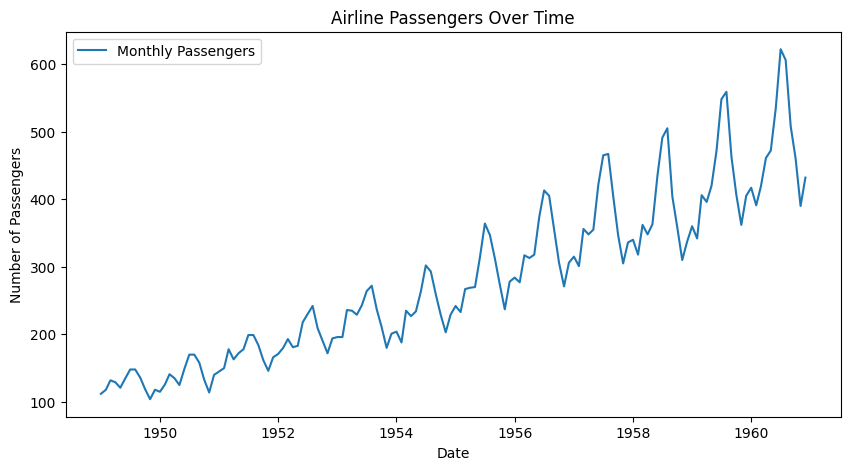

In [27]:
plt.figure(figsize=(10,5))
plt.plot(df['Passgr'], label='Monthly Passengers')
plt.title("Airline Passengers Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()


In [28]:
# Ensure it's a time series with monthly frequency
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='MS')


In [29]:
# --- Additive Decomposition ---
additive_decomp = seasonal_decompose(df['Passgr'], model='additive')


In [31]:

# --- Multiplicative Decomposition ---
multiplicative_decomp = seasonal_decompose(df['Passgr'], model='multiplicative')


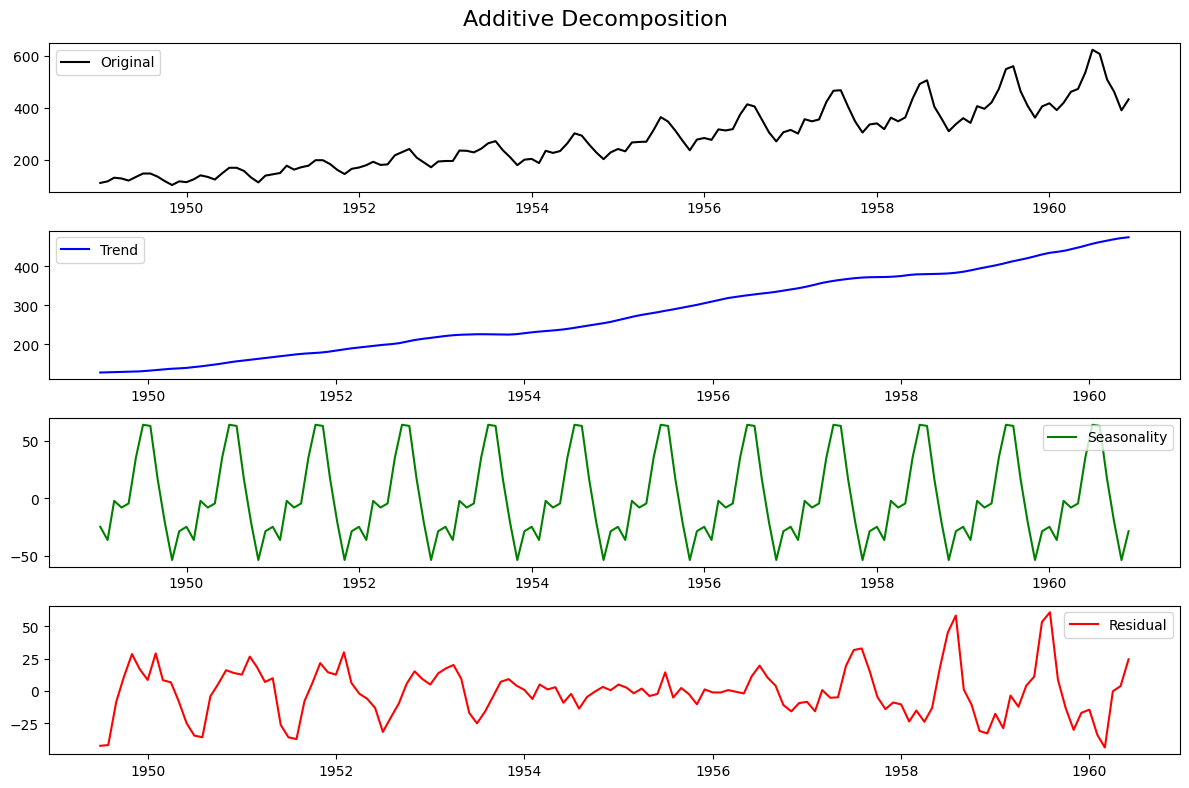

In [32]:



# Plot Additive Decomposition
plt.figure(figsize=(12,8))
plt.suptitle("Additive Decomposition", fontsize=16)
plt.subplot(411)
plt.plot(df['Passgr'], label='Original', color='black')
plt.legend()
plt.subplot(412)
plt.plot(additive_decomp.trend, label='Trend', color='blue')
plt.legend()
plt.subplot(413)
plt.plot(additive_decomp.seasonal, label='Seasonality', color='green')
plt.legend()
plt.subplot(414)
plt.plot(additive_decomp.resid, label='Residual', color='red')
plt.legend()
plt.tight_layout()
plt.show()



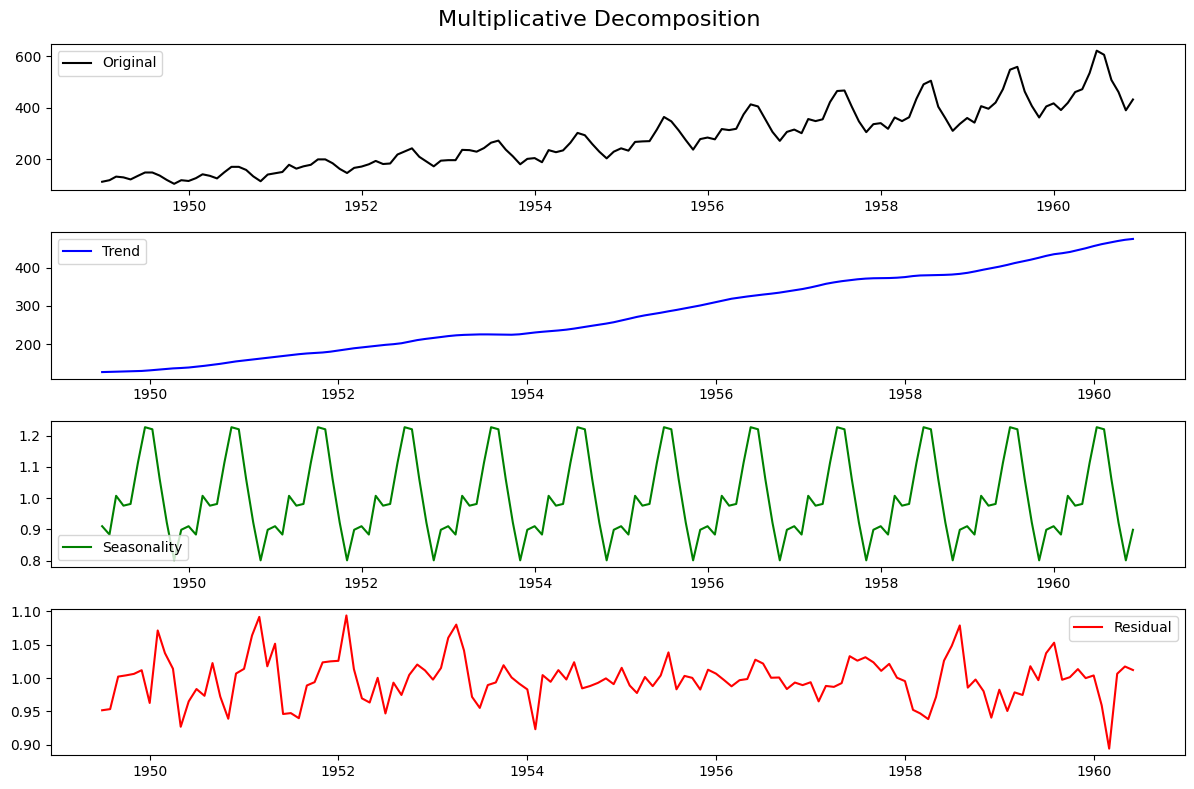

In [33]:
# Plot Multiplicative Decomposition
plt.figure(figsize=(12,8))
plt.suptitle("Multiplicative Decomposition", fontsize=16)
plt.subplot(411)
plt.plot(df['Passgr'], label='Original', color='black')
plt.legend()
plt.subplot(412)
plt.plot(multiplicative_decomp.trend, label='Trend', color='blue')
plt.legend()
plt.subplot(413)
plt.plot(multiplicative_decomp.seasonal, label='Seasonality', color='green')
plt.legend()
plt.subplot(414)
plt.plot(multiplicative_decomp.resid, label='Residual', color='red')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
print("=== Additive Decomposition ===")
print("Trend:\n", additive_decomp.trend.dropna().head())
print("Seasonality:\n", additive_decomp.seasonal.head(12))
print("Residual:\n", additive_decomp.resid.dropna().head())


=== Additive Decomposition ===
Trend:
 1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
1949-11-01    129.000000
Freq: MS, Name: trend, dtype: float64
Seasonality:
 1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
1949-06-01    35.402778
1949-07-01    63.830808
1949-08-01    62.823232
1949-09-01    16.520202
1949-10-01   -20.642677
1949-11-01   -53.593434
1949-12-01   -28.619949
Freq: MS, Name: seasonal, dtype: float64
Residual:
 1949-07-01   -42.622475
1949-08-01   -42.073232
1949-09-01    -8.478535
1949-10-01    11.059343
1949-11-01    28.593434
Freq: MS, Name: resid, dtype: float64


In [14]:

print("\n=== Multiplicative Decomposition ===")
print("Trend:\n", multiplicative_decomp.trend.dropna().head())
print("Seasonality:\n", multiplicative_decomp.seasonal.head(12))
print("Residual:\n", multiplicative_decomp.resid.dropna().head())



=== Multiplicative Decomposition ===
Trend:
 1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
1949-11-01    129.000000
Freq: MS, Name: trend, dtype: float64
Seasonality:
 1949-01-01    0.910230
1949-02-01    0.883625
1949-03-01    1.007366
1949-04-01    0.975906
1949-05-01    0.981378
1949-06-01    1.112776
1949-07-01    1.226556
1949-08-01    1.219911
1949-09-01    1.060492
1949-10-01    0.921757
1949-11-01    0.801178
1949-12-01    0.898824
Freq: MS, Name: seasonal, dtype: float64
Residual:
 1949-07-01    0.951664
1949-08-01    0.953401
1949-09-01    1.002220
1949-10-01    1.004028
1949-11-01    1.006270
Freq: MS, Name: resid, dtype: float64


Alright — you’ve pasted the numerical outputs from a **time series decomposition** (both **Additive** and **Multiplicative**) for the **AirPassengers** dataset, so let’s break down what these numbers are telling us in detail.

---

## **1. Understanding the Components**

Time series decomposition splits data into three main parts:

1. **Trend** – Long-term movement in the data (upwards, downwards, or flat).
2. **Seasonality** – Repeated pattern in the data over fixed time periods (e.g., yearly, monthly).
3. **Residual** – The noise or random variation left after removing trend and seasonality.

You’ve performed **both additive and multiplicative decomposition**, so we’ll interpret each.

---

## **2. Additive Decomposition Analysis**

Formula:

$$
y(t) = Trend(t) + Seasonality(t) + Residual(t)
$$

### **Trend**

Example (July 1949 to Nov 1949):

| Month    | Trend Value |
| -------- | ----------- |
| Jul-1949 | 126.79      |
| Aug-1949 | 127.25      |
| Sep-1949 | 127.96      |
| Oct-1949 | 128.58      |
| Nov-1949 | 129.00      |

* These are smoothed values showing the **underlying long-term passenger growth**.
* Numbers are increasing very slowly, suggesting a **slight upward trend** in the number of passengers during that period.

---

### **Seasonality**

Example (Jan to Dec pattern, same each year):

| Month | Seasonal Effect |
| ----- | --------------- |
| Jan   | -24.75          |
| Feb   | -36.19          |
| Mar   | -2.24           |
| Apr   | -8.04           |
| May   | -4.51           |
| Jun   | +35.40          |
| Jul   | +63.83          |
| Aug   | +62.82          |
| Sep   | +16.52          |
| Oct   | -20.64          |
| Nov   | -53.59          |
| Dec   | -28.62          |

* **Interpretation**:

  * **Negative values** → months below the trend (e.g., Feb and Nov are travel-low months).
  * **Positive values** → months above the trend (e.g., Jun–Aug have travel peaks).
* **Peak travel months:** July & August (large positive seasonal effects).
* **Low travel months:** November & February (large negative seasonal effects).

---

### **Residual**

Example:

| Month    | Residual |
| -------- | -------- |
| Jul-1949 | -42.62   |
| Aug-1949 | -42.07   |
| Sep-1949 | -8.48    |
| Oct-1949 | +11.06   |
| Nov-1949 | +28.59   |

* This is **what’s left after removing trend & seasonality**.
* Large negative residual → the actual value was much lower than expected.
* Large positive residual → the actual value was higher than expected.
* In July–Aug 1949, passengers were **much fewer than expected** for that season and trend.

---

## **3. Multiplicative Decomposition Analysis**

Formula:

$$
y(t) = Trend(t) \times Seasonality(t) \times Residual(t)
$$

Here, instead of adding, the components multiply.

### **Trend**

* Same trend values as additive (126.79 → 129.00).
* Still shows **slow upward growth**.

---

### **Seasonality**

Example:

| Month | Seasonal Factor |
| ----- | --------------- |
| Jan   | 0.91            |
| Feb   | 0.88            |
| Mar   | 1.01            |
| Apr   | 0.98            |
| May   | 0.98            |
| Jun   | 1.11            |
| Jul   | 1.23            |
| Aug   | 1.22            |
| Sep   | 1.06            |
| Oct   | 0.92            |
| Nov   | 0.80            |
| Dec   | 0.90            |

* **Interpretation**:

  * Values **> 1** → month has more passengers than trend predicts (e.g., July = 1.23 means \~23% above trend).
  * Values **< 1** → month has fewer passengers than trend predicts (e.g., Nov = 0.80 means \~20% below trend).
* This gives **relative seasonal strength** rather than absolute passenger changes.

---

### **Residual**

Example:

| Month    | Residual Factor |
| -------- | --------------- |
| Jul-1949 | 0.95            |
| Aug-1949 | 0.95            |
| Sep-1949 | 1.00            |
| Oct-1949 | 1.00            |
| Nov-1949 | 1.01            |

* Values close to **1** mean actual values are very close to expected.
* < 1 means actual was lower, > 1 means higher.
* In multiplicative decomposition, residuals tend to be smaller because they are relative ratios, not absolute differences.

---

## **4. Overall Insights**

* **Trend**: Steady growth in passengers over the years (post-WWII travel boom).
* **Seasonality**:

  * Peaks in **June–August** (likely due to summer vacations).
  * Troughs in **November–February** (low travel season).
* **Residual**:

  * Mostly small variations — meaning trend & seasonality explain most of the patterns.
  * A few months had unexpected drops (July–Aug 1949 in additive residual).
